# 📚 Regressão de Vetores de Suporte (SVR)
## Base de Dados: Student Performance (UCI)

**Objetivo:** Prever a **nota final (G3)** de estudantes do ensino secundário em Portugal utilizando Support Vector Regression (SVR) com diferentes kernels e comparar com a Regressão Linear clássica.

**Fonte:** Cortez, P. & Silva, A. (2008). [Student Performance Dataset – UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/320/student+performance)

---

### 🗺️ Roteiro da aula
| # | Etapa | O que vamos aprender |
|---|---|---|
| 1 | Instalação e importações | Ambiente de trabalho |
| 2 | Carregamento e inspeção | Conhecer os dados |
| 3 | Análise exploratória (EDA) | Entender o problema |
| 4 | Pré-processamento | Por que o SVR exige padronização? |
| 5 | SVR com diferentes kernels | Como o kernel muda os resultados? |
| 6 | Tuning de hiperparâmetros | Como C, ε e γ controlam o modelo? |
| 7 | Comparação com Regressão Linear | Quando o SVR vale a pena? |
| 8 | Visualizações e diagnóstico | O que os erros nos dizem? |
| 9 | Conclusões consolidadas | Síntese dos aprendizados |

> 💡 **Como usar este notebook:** ao longo do código você encontrará blocos marcados com:
> - 🔍 **Observe** — preste atenção neste resultado
> - 💬 **Reflita** — uma pergunta para você pensar antes ou depois de rodar
> - ✏️ **Experimente** — modifique o código e veja o que muda
> - ✅ **Conclusão parcial** — o que já aprendemos até aqui

---
## 1. Instalação e Importações

In [ ]:
!pip install ucimlrepo -q

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 12
sns.set_theme(style='whitegrid', palette='muted')

print('✅ Importações concluídas!')

✅ Importações concluídas!


---
## 2. Carregamento e Inspeção dos Dados

> 💬 **Reflita antes de rodar:** Quais fatores você acredita que mais influenciam o desempenho de um estudante? Liste mentalmente **3 variáveis** que você apostaria serem as mais importantes. Vamos revisitar essa previsão na seção de conclusões.

In [ ]:
dataset = fetch_ucirepo(id=320)

X_raw = dataset.data.features.copy()
y_raw = dataset.data.targets.copy()

df = pd.concat([X_raw, y_raw], axis=1)

print(f'Dimensões do dataset : {df.shape}')
print(f'Número de features   : {X_raw.shape[1]}')
print(f'Variável alvo        : G3 (nota final — escala 0 a 20)')
print(f'\nVariáveis disponíveis:')
print(df.columns.tolist())

Dimensões do dataset : (649, 33)
Número de features   : 30
Variável alvo        : G3 (nota final — escala 0 a 20)

Variáveis disponíveis:
['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']


In [ ]:
df.head(10)

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13
5,GP,M,16,U,LE3,T,4,3,services,other,...,5,4,2,1,2,5,6,12,12,13
6,GP,M,16,U,LE3,T,2,2,other,other,...,4,4,4,1,1,3,0,13,12,13
7,GP,F,17,U,GT3,A,4,4,other,teacher,...,4,1,4,1,1,1,2,10,13,13
8,GP,M,15,U,LE3,A,3,2,services,other,...,4,2,2,1,1,1,0,15,16,17
9,GP,M,15,U,GT3,T,3,4,other,other,...,5,5,1,1,1,5,0,12,12,13


> 🔍 **Observe:** Existem três colunas de notas — **G1** (1º período), **G2** (2º período) e **G3** (nota final).  
> Mais à frente, precisaremos tomar uma decisão importante sobre o que fazer com G1 e G2. Pense agora: você as usaria como preditores?

In [35]:
df.describe().round(2)

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,649.00,649.00,649.00,649.00,649.00,649.00,649.00,649.00,649.00,649.00,649.00,649.00,649.00,649.00,649.00,649.00
mean,16.74,2.51,2.31,1.57,1.93,0.22,3.93,3.18,3.18,1.50,2.28,3.54,3.66,11.40,11.57,11.91
std,1.22,1.13,1.10,0.75,0.83,0.59,0.96,1.05,1.18,0.92,1.28,1.45,4.64,2.75,2.91,3.23
min,15.00,0.00,0.00,1.00,1.00,0.00,1.00,1.00,1.00,1.00,1.00,1.00,0.00,0.00,0.00,0.00
25%,16.00,2.00,1.00,1.00,1.00,0.00,4.00,3.00,2.00,1.00,1.00,2.00,0.00,10.00,10.00,10.00
50%,17.00,2.00,2.00,1.00,2.00,0.00,4.00,3.00,3.00,1.00,2.00,4.00,2.00,11.00,11.00,12.00
75%,18.00,4.00,3.00,2.00,2.00,0.00,5.00,4.00,4.00,2.00,3.00,5.00,6.00,13.00,13.00,14.00
max,22.00,4.00,4.00,4.00,4.00,3.00,5.00,5.00,5.00,5.00,5.00,5.00,32.00,19.00,19.00,19.00


In [ ]:
print('Valores ausentes por coluna:')
print(df.isnull().sum())
print(f'\nTotal: {df.isnull().sum().sum()} valor(es) ausente(s)')

Valores ausentes por coluna:
school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64

Total: 0 valor(es) ausente(s)


> ✅ **Conclusão parcial:** A base está completa (sem missing values) e bem estruturada. Temos variáveis numéricas e categóricas, e nosso alvo **G3** é contínuo (0–20) — trata-se de um problema de **regressão**.

---
## 3. Análise Exploratória (EDA)

> 💬 **Reflita:** O SVR aprende com os dados de treino buscando uma função que minimize erros. Se a distribuição da variável alvo for muito assimétrica ou tiver concentrações incomuns, isso pode afetar o modelo. Vamos investigar antes de modelar.

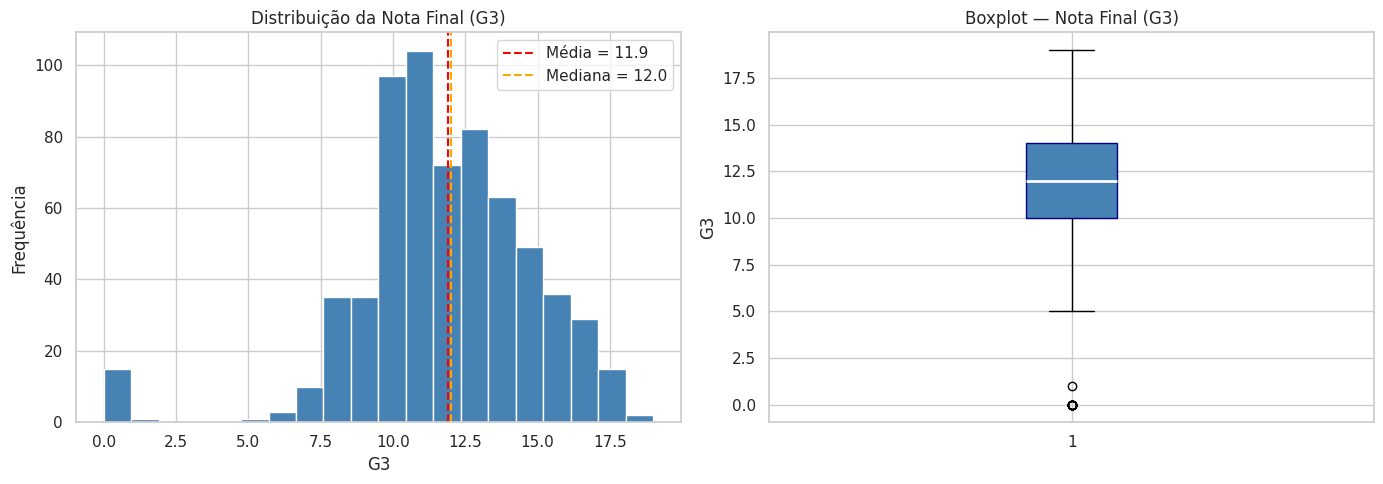

Estudantes com G3 = 0 : 15 (2.3%)
Assimetria (skewness)  : -0.913


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['G3'], bins=20, color='steelblue', edgecolor='white')
axes[0].axvline(df['G3'].mean(),   color='red',    linestyle='--', label=f'Média = {df["G3"].mean():.1f}')
axes[0].axvline(df['G3'].median(), color='orange', linestyle='--', label=f'Mediana = {df["G3"].median():.1f}')
axes[0].set_title('Distribuição da Nota Final (G3)')
axes[0].set_xlabel('G3')
axes[0].set_ylabel('Frequência')
axes[0].legend()

axes[1].boxplot(df['G3'], patch_artist=True,
                boxprops=dict(facecolor='steelblue', color='navy'),
                medianprops=dict(color='white', linewidth=2))
axes[1].set_title('Boxplot — Nota Final (G3)')
axes[1].set_ylabel('G3')

plt.tight_layout()
plt.show()

zeros = (df['G3'] == 0).sum()
print(f'Estudantes com G3 = 0 : {zeros} ({zeros/len(df)*100:.1f}%)')
print(f'Assimetria (skewness)  : {df["G3"].skew():.3f}')

> 🔍 **Observe:** Uma parcela dos estudantes tem nota zero — possivelmente desistências ou reprovações sem avaliação. Isso cria uma concentração artificial no extremo inferior.
>
> 💬 **Reflita:**
> 1. Esses zeros deveriam ser mantidos ou excluídos? Que impacto essa decisão teria nas métricas? A presença de muitos valores zero em G3 cria assimetria e pode distorcer métricas como RMSE, especialmente nas faixas mais baixas de nota.
> 2. Uma nota zero representa o mesmo fenômeno que uma nota 4? O modelo consegue distinguir os dois casos? Manter os zeros preserva a realidade do fenômeno, mas aumenta o erro médio, então remover eles melhora métricas, porém perde informação relevante.
> 3. Guarde essa observação — ela reaparecerá quando analisarmos os erros por faixa de nota.

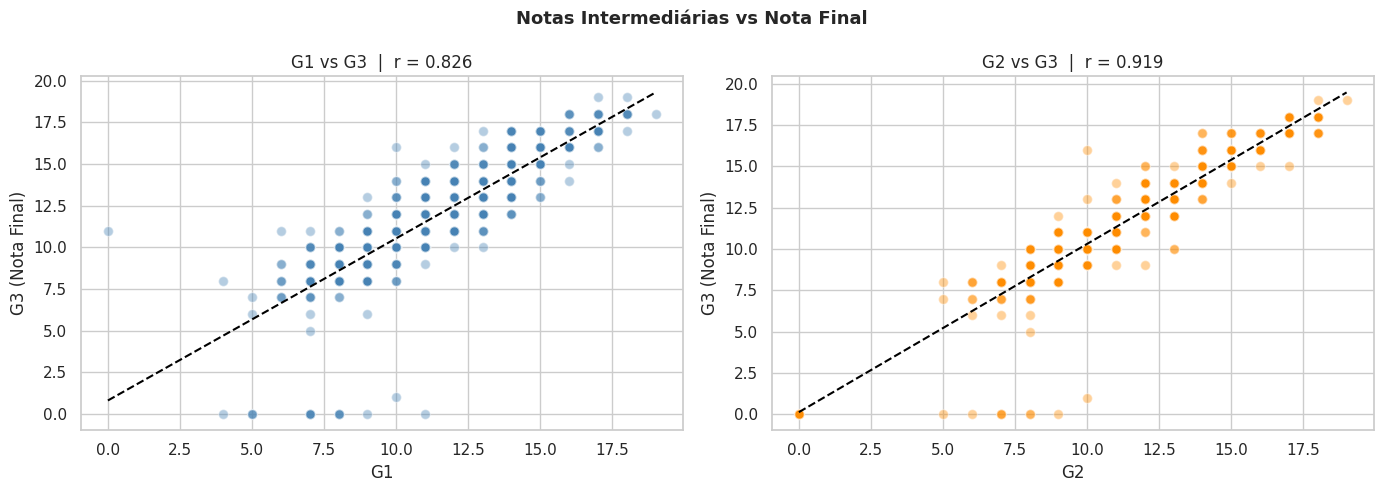

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (col, cor) in zip(axes, [('G1', 'steelblue'), ('G2', 'darkorange')]):
    ax.scatter(df[col], df['G3'], alpha=0.4, color=cor, edgecolors='white', s=50)
    r = df[col].corr(df['G3'])
    m, b = np.polyfit(df[col], df['G3'], 1)
    xseq = np.linspace(df[col].min(), df[col].max(), 100)
    ax.plot(xseq, m*xseq + b, color='black', linewidth=1.5, linestyle='--')
    ax.set_title(f'{col} vs G3  |  r = {r:.3f}')
    ax.set_xlabel(col)
    ax.set_ylabel('G3 (Nota Final)')

plt.suptitle('Notas Intermediárias vs Nota Final', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

> 🔍 **Observe:** G1 e G2 têm correlação **muito alta** com G3 (acima de 0.8). Se as incluirmos como preditores, o modelo "trapaceia" — torna-se trivialmente fácil prever G3 a partir das notas anteriores, e aprendemos pouco sobre os fatores reais de sucesso.
>
> ✏️ **Experimente (depois de terminar o notebook):** volte aqui e responda — o R² muda muito se incluirmos G1 e G2 como features? O experimento bônus na seção 9 responde essa pergunta.

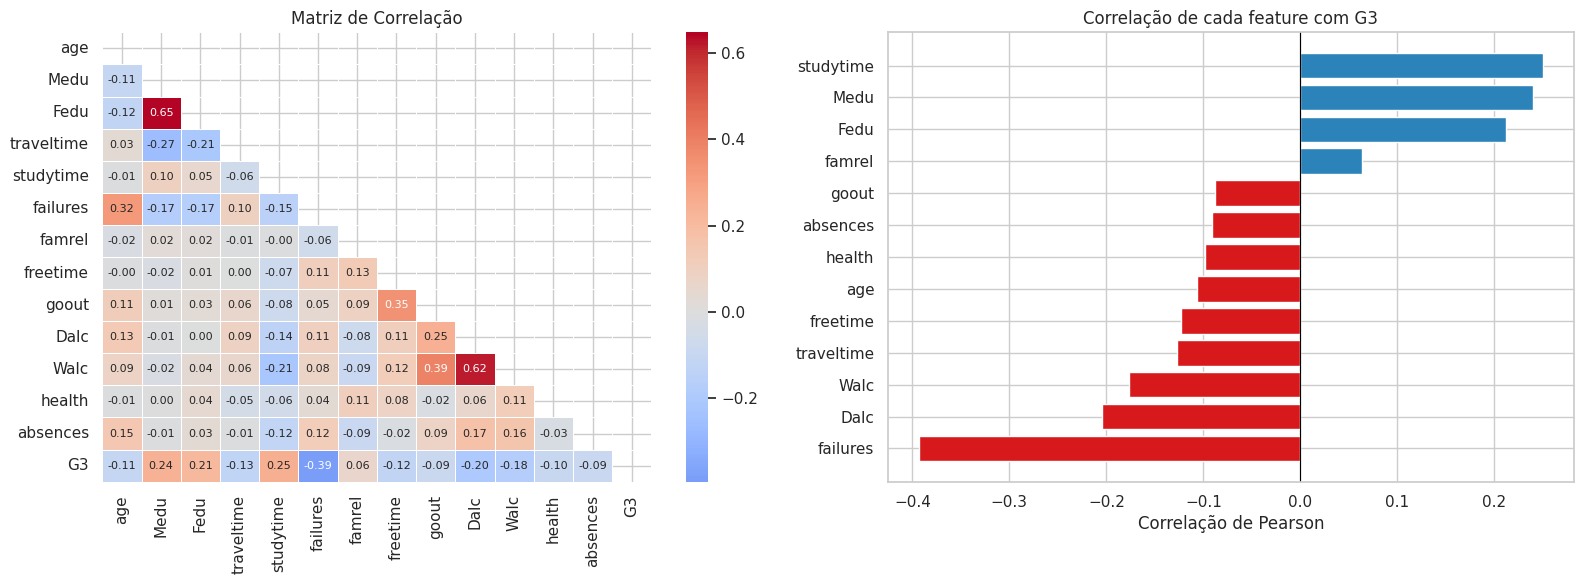

In [ ]:
num_cols = ['age','Medu','Fedu','traveltime','studytime','failures',
            'famrel','freetime','goout','Dalc','Walc','health','absences','G3']

corr = df[num_cols].corr()
g3_corr = corr['G3'].drop('G3').sort_values()
cores_bar = ['#d7191c' if v < 0 else '#2b83ba' for v in g3_corr]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, annot_kws={'size': 8}, ax=axes[0])
axes[0].set_title('Matriz de Correlação')

axes[1].barh(g3_corr.index, g3_corr.values, color=cores_bar, edgecolor='white')
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Correlação de cada feature com G3')
axes[1].set_xlabel('Correlação de Pearson')

plt.tight_layout()
plt.show()

> 🔍 **Observe:** As correlações entre as features e G3 (excluindo G1 e G2) são relativamente **baixas** — nenhuma variável isolada explica bem a nota final.
>
> 💬 **Reflita:**
> 1. Isso significa que os dados são "ruins" ou que o fenômeno é genuinamente complexo? Isso indica que o fenômeno é realmente complexo e depende da combinação de vários fatores, não de uma única variável.
> 2. Um modelo linear consegue capturar bem a relação quando nenhuma variável tem correlação forte com o alvo? Um modelo linear tende a ter dificuldade, pois ele funciona melhor quando há relações fortes e diretas com o alvo.
> 3. Quais variáveis têm correlação negativa com G3? Faz sentido intuitivo? Variáveis como reprovações anteriores, consumo de álcool e saídas frequentes têm correlação negativa, o que faz sentido intuitivamente.
>
> Guarde essa reflexão — ela justificará a escolha do kernel RBF mais adiante.

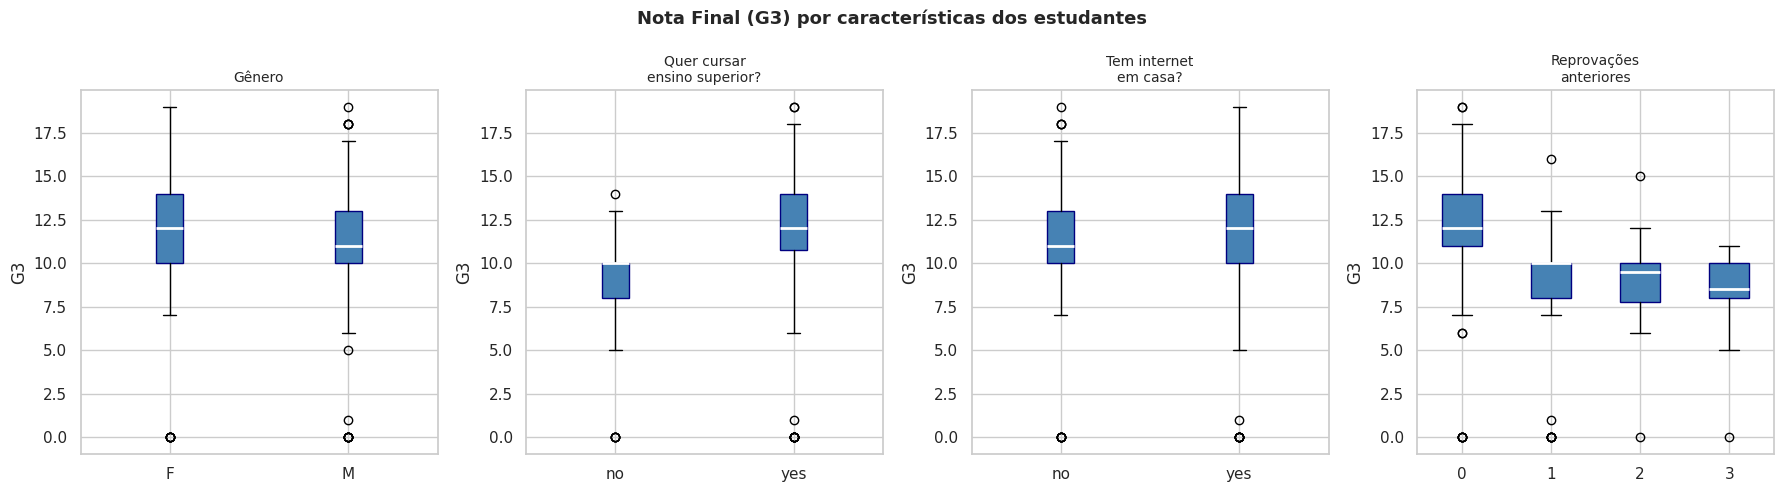

In [ ]:
cats = [
    ('sex',      'Gênero'),
    ('higher',   'Quer cursar\nensino superior?'),
    ('internet', 'Tem internet\nem casa?'),
    ('failures', 'Reprovações\nanteriores')
]

fig, axes = plt.subplots(1, 4, figsize=(18, 5))

for ax, (col, titulo) in zip(axes, cats):
    grupos = [df.loc[df[col] == v, 'G3'].values for v in sorted(df[col].unique())]
    labels = sorted(df[col].unique())
    ax.boxplot(grupos, labels=labels, patch_artist=True,
               boxprops=dict(facecolor='steelblue', color='navy'),
               medianprops=dict(color='white', linewidth=2))
    ax.set_title(titulo, fontsize=10)
    ax.set_ylabel('G3')

plt.suptitle('Nota Final (G3) por características dos estudantes',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

> 🔍 **Observe:**
> - Estudantes que **desejam cursar o ensino superior** têm notas sistematicamente mais altas.
> - Estudantes com **mais reprovações anteriores** têm desempenho muito inferior.
> - O acesso à internet e o gênero têm impactos menores.
>
> 💬 **Reflita:** Essas relações parecem **lineares** (uma linha reta descreveria bem a relação entre "nº de reprovações" e G3)? Ou são mais complexas, com limiares e interações entre variáveis?   Elas não parecem totalmente lineares, pois há limiares e efeitos diferentes conforme o número de reprovações aumenta.
> Isso nos dá uma pista sobre qual tipo de kernel o SVR deve usar.
>
> ✅ **Conclusão parcial da EDA:** O problema é genuinamente difícil — as features individualmente têm baixo poder preditivo, e há relações que provavelmente não são lineares. Isso justifica testar modelos mais flexíveis.

---
## 4. Pré-processamento

### Por que o SVR precisa de pré-processamento cuidadoso?

O SVR calcula **distâncias** entre pontos no espaço de features para construir a função de regressão. Se uma variável tiver escala muito maior que as outras (ex: `absences` chega a 75; `age` vai de 15 a 22), ela dominará o cálculo de distâncias e distorcerá o modelo inteiro.

> 💬 **Reflita:** A Regressão Linear (OLS) também precisa de padronização? Em quais situações ela faz diferença para os coeficientes estimados? A regressão linear não precisa de padronização para prever corretamente, mas ela faz diferença quando queremos comparar os coeficientes entre variáveis em escalas diferentes ou melhorar a estabilidade numérica do modelo.

In [ ]:
df_proc = df.copy()

cat_cols = df_proc.select_dtypes(include='object').columns.tolist()
print(f'Variáveis categóricas ({len(cat_cols)}): {cat_cols}')

le = LabelEncoder()
for col in cat_cols:
    df_proc[col] = le.fit_transform(df_proc[col])

print('\n✅ Label Encoding aplicado — variáveis categóricas convertidas para inteiros.')

Variáveis categóricas (17): ['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']

✅ Label Encoding aplicado — variáveis categóricas convertidas para inteiros.


> 💬 **Reflita:** O Label Encoding atribui valores inteiros **ordenados** às categorias (ex: 'F'→0, 'M'→1). Para variáveis como `sex` ou `school`, isso cria uma **ordem artificial** que não existe na realidade.  
> Qual seria a alternativa? Em quais situações o One-Hot Encoding seria mais adequado — e quais seriam seus custos neste dataset? A alternativa é usar One-Hot Encoding, que é mais adequado para variáveis categóricas sem ordem, mas aumenta o número de colunas e o custo computacional do modelo.

In [ ]:
# ⚠️ Decisão metodológica: excluir G1 e G2
# Queremos que o modelo aprenda com características do estudante — não com notas anteriores.
# Se incluíssemos G1 e G2, a previsão seria trivial e aprendemos pouco sobre os fatores reais.

features = [col for col in df_proc.columns if col not in ['G1', 'G2', 'G3']]
X = df_proc[features]
y = df_proc['G3']

print(f'Features utilizadas ({len(features)}):')
print(features)
print(f'\n⚠️  G1 e G2 foram EXCLUÍDAS por decisão metodológica.')
print(f'    O experimento bônus na seção 9 mostrará o impacto de incluí-las.')

Features utilizadas (30):
['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences']

⚠️  G1 e G2 foram EXCLUÍDAS por decisão metodológica.
    O experimento bônus na seção 9 mostrará o impacto de incluí-las.


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)
print(f'Treino : {X_train.shape[0]} amostras ({X_train.shape[0]/len(X)*100:.0f}%)')
print(f'Teste  : {X_test.shape[0]} amostras ({X_test.shape[0]/len(X)*100:.0f}%)')

Treino : 519 amostras (80%)
Teste  : 130 amostras (20%)


In [ ]:
print('📏 Escalas ANTES da padronização — repare nas diferenças:')
print(X_train.describe().loc[['mean', 'std', 'min', 'max']].round(2).to_string())

📏 Escalas ANTES da padronização — repare nas diferenças:
      school   sex    age  address  famsize  Pstatus  Medu  Fedu  Mjob  Fjob  reason  guardian  traveltime  studytime  failures  schoolsup  famsup  paid  activities  nursery  higher  internet  romantic  famrel  freetime  goout  Dalc  Walc  health  absences
mean    0.35  0.43  16.78     0.69     0.28     0.89  2.49  2.28  1.90  2.21    1.10      0.84        1.58       1.90      0.23        0.1    0.62  0.06        0.49      0.8    0.89      0.76      0.37    3.93      3.20   3.23  1.52  2.29    3.54      3.69
std     0.48  0.50   1.24     0.46     0.45     0.32  1.12  1.08  1.24  0.84    1.19      0.51        0.76       0.81      0.59        0.3    0.49  0.24        0.50      0.4    0.31      0.43      0.48    0.96      1.06   1.18  0.97  1.31    1.44      4.68
min     0.00  0.00  15.00     0.00     0.00     0.00  0.00  0.00  0.00  0.00    0.00      0.00        1.00       1.00      0.00        0.0    0.00  0.00        0.00      0.

In [ ]:
# Padronização: fit SOMENTE no treino, aplica no teste
# Isso evita data leakage — o teste simula dados futuros desconhecidos.
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

df_scaled = pd.DataFrame(X_train_sc, columns=features)
print('📏 Escalas APÓS padronização — todas em torno de 0 com desvio ~1:')
print(df_scaled.describe().loc[['mean', 'std', 'min', 'max']].round(3).to_string())

📏 Escalas APÓS padronização — todas em torno de 0 com desvio ~1:
      school    sex    age  address  famsize  Pstatus   Medu   Fedu   Mjob   Fjob  reason  guardian  traveltime  studytime  failures  schoolsup  famsup   paid  activities  nursery  higher  internet  romantic  famrel  freetime  goout   Dalc   Walc  health  absences
mean   0.000  0.000 -0.000    0.000    0.000    0.000 -0.000  0.000 -0.000  0.000   0.000     0.000       0.000      0.000     0.000     -0.000   0.000 -0.000      -0.000    0.000  -0.000     0.000    -0.000   0.000     0.000  0.000 -0.000 -0.000   0.000     0.000
std    1.001  1.001  1.001    1.001    1.001    1.001  1.001  1.001  1.001  1.001   1.001     1.001       1.001      1.001     1.001      1.001   1.001  1.001       1.001    1.001   1.001     1.001     1.001   1.001     1.001  1.001  1.001  1.001   1.001     1.001
min   -0.738 -0.875 -1.438   -1.491   -0.620   -2.792 -2.225 -2.104 -1.532 -2.632  -0.928    -1.646      -0.754     -1.111    -0.382     -0.

> 🔍 **Observe:** Após a padronização, **todas as features têm média ≈ 0 e desvio padrão ≈ 1**. Agora o SVR pode comparar distâncias de forma justa entre todas as variáveis.
>
> 🔍 **Observe também:** Fizemos `fit` do scaler **apenas no treino** e apenas `transform` no teste. Por quê? Porque fazer `fit` no teste seria uma forma de *data leakage* — o modelo "veria" informação do futuro durante o treinamento.
>
> ✏️ **Experimente:** treine o SVR (seção 5) sem padronizar — use `X_train` e `X_test` diretamente — e compare o RMSE. A degradação costuma ser expressiva.
>
> ✅ **Conclusão parcial:** O pré-processamento correto (encoding + padronização + divisão sem leakage) é **tão importante quanto a escolha do algoritmo**. Um SVR mal pré-processado perderá para uma Regressão Linear bem configurada.

---
## 5. SVR com Diferentes Kernels

### 🧠 Intuição do SVR

Na Regressão Linear, minimizamos a **soma dos quadrados dos erros** de todos os pontos.  
No SVR, definimos uma **faixa de tolerância (ε-tube)**: pontos **dentro** da faixa não geram penalidade. Apenas pontos **fora** da faixa são penalizados — o modelo foca energia nos casos mais difíceis e é naturalmente mais robusto a outliers.

```
    G3 ↑
       │     ╔══════════════╗   ← limite superior do ε-tube
       │  ·  ║ · · · · · · ║ ·
       │     ║ ─────────── ║   ← função de regressão (f)
       │  ·  ║ · · · · · · ║ ·
       │     ╚══════════════╝   ← limite inferior do ε-tube
       │  *                     ← ponto FORA da faixa (penalizado)
       └────────────────────────► features
```

| Hiperparâmetro | Papel no SVR |
|---|---|
| `kernel` | Define como o espaço de features é transformado |
| `C` | Penalidade para pontos fora do ε-tube (↑C = menos tolerância) |
| `epsilon (ε)` | Largura da faixa de tolerância (↑ε = modelo mais simples) |
| `gamma` | Alcance de influência de cada ponto (apenas kernels não-lineares) |

In [ ]:
def avaliar(nome, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    print(f'  RMSE : {rmse:.4f}  ← erro médio em pontos de nota (mesma unidade de G3)')
    print(f'  MAE  : {mae:.4f}')
    print(f'  R²   : {r2:.4f}  ← proporção da variância de G3 explicada pelo modelo')
    return {'Modelo': nome, 'RMSE': round(rmse, 4),
            'MAE': round(mae, 4), 'R²': round(r2, 4)}

resultados = []
previsoes  = {}

In [ ]:
# ── Kernel Linear ──────────────────────────────────────────────────────
# Traça um hiperplano sem transformação do espaço. Equivale conceitualmente
# a uma regressão linear, mas com a lógica do ε-tube do SVR.
print('=' * 55)
print('SVR — Kernel Linear  (C=1, ε=0.5)')
print('=' * 55)

svr_linear = SVR(kernel='linear', C=1.0, epsilon=0.5)
svr_linear.fit(X_train_sc, y_train)
y_pred_linear = svr_linear.predict(X_test_sc)
previsoes['SVR Linear'] = y_pred_linear

res = avaliar('SVR Linear', y_test, y_pred_linear)
resultados.append(res)

n_sv = svr_linear.support_vectors_.shape[0]
print(f'  Vetores de suporte: {n_sv}/{len(X_train)} amostras ({n_sv/len(X_train)*100:.1f}%)')

SVR — Kernel Linear  (C=1, ε=0.5)
  RMSE : 2.8075  ← erro médio em pontos de nota (mesma unidade de G3)
  MAE  : 2.0624
  R²   : 0.1917  ← proporção da variância de G3 explicada pelo modelo
  Vetores de suporte: 432/519 amostras (83.2%)


> 🔍 **Observe:** O número de **vetores de suporte** indica quantas amostras ficaram fora do ε-tube e influenciam diretamente a função de regressão. Um número muito alto pode indicar que ε está pequeno ou que os dados são muito dispersos.
>
> 💬 **Reflita:** Se o SVR linear e a Regressão Linear são conceitualmente similares, por que usaríamos o SVR linear em vez de OLS? (Pense em robustez a outliers e na lógica do ε-tube.) Usamos o SVR linear porque ele é mais robusto a outliers, já que penaliza apenas os pontos fora do ε-tube, enquanto a regressão linear penaliza todos os erros igualmente.

In [ ]:
# ── Kernel RBF (Radial Basis Function) ────────────────────────────────
# Mapeia os dados para um espaço de dimensão muito maior (possivelmente
# infinita), permitindo capturar relações não-lineares complexas.
print('=' * 55)
print('SVR — Kernel RBF  (C=1, ε=0.5, gamma=scale)')
print('=' * 55)

svr_rbf = SVR(kernel='rbf', C=1.0, epsilon=0.5, gamma='scale')
svr_rbf.fit(X_train_sc, y_train)
y_pred_rbf = svr_rbf.predict(X_test_sc)
previsoes['SVR RBF'] = y_pred_rbf

res = avaliar('SVR RBF', y_test, y_pred_rbf)
resultados.append(res)

n_sv = svr_rbf.support_vectors_.shape[0]
print(f'  Vetores de suporte: {n_sv}/{len(X_train)} amostras ({n_sv/len(X_train)*100:.1f}%)')

SVR — Kernel RBF  (C=1, ε=0.5, gamma=scale)
  RMSE : 2.8013  ← erro médio em pontos de nota (mesma unidade de G3)
  MAE  : 2.0216
  R²   : 0.1953  ← proporção da variância de G3 explicada pelo modelo
  Vetores de suporte: 416/519 amostras (80.2%)


In [ ]:
# ── Kernel Polinomial ─────────────────────────────────────────────────
# Captura interações entre features até o grau definido.
# Grau 3 → considera combinações até x1*x2*x3.
print('=' * 55)
print('SVR — Kernel Polinomial  (grau=3, C=1, ε=0.5)')
print('=' * 55)

svr_poly = SVR(kernel='poly', C=1.0, epsilon=0.5, degree=3, gamma='scale')
svr_poly.fit(X_train_sc, y_train)
y_pred_poly = svr_poly.predict(X_test_sc)
previsoes['SVR Polinomial'] = y_pred_poly

res = avaliar('SVR Polinomial', y_test, y_pred_poly)
resultados.append(res)

n_sv = svr_poly.support_vectors_.shape[0]
print(f'  Vetores de suporte: {n_sv}/{len(X_train)} amostras ({n_sv/len(X_train)*100:.1f}%)')

SVR — Kernel Polinomial  (grau=3, C=1, ε=0.5)
  RMSE : 2.7986  ← erro médio em pontos de nota (mesma unidade de G3)
  MAE  : 2.0421
  R²   : 0.1968  ← proporção da variância de G3 explicada pelo modelo
  Vetores de suporte: 441/519 amostras (85.0%)


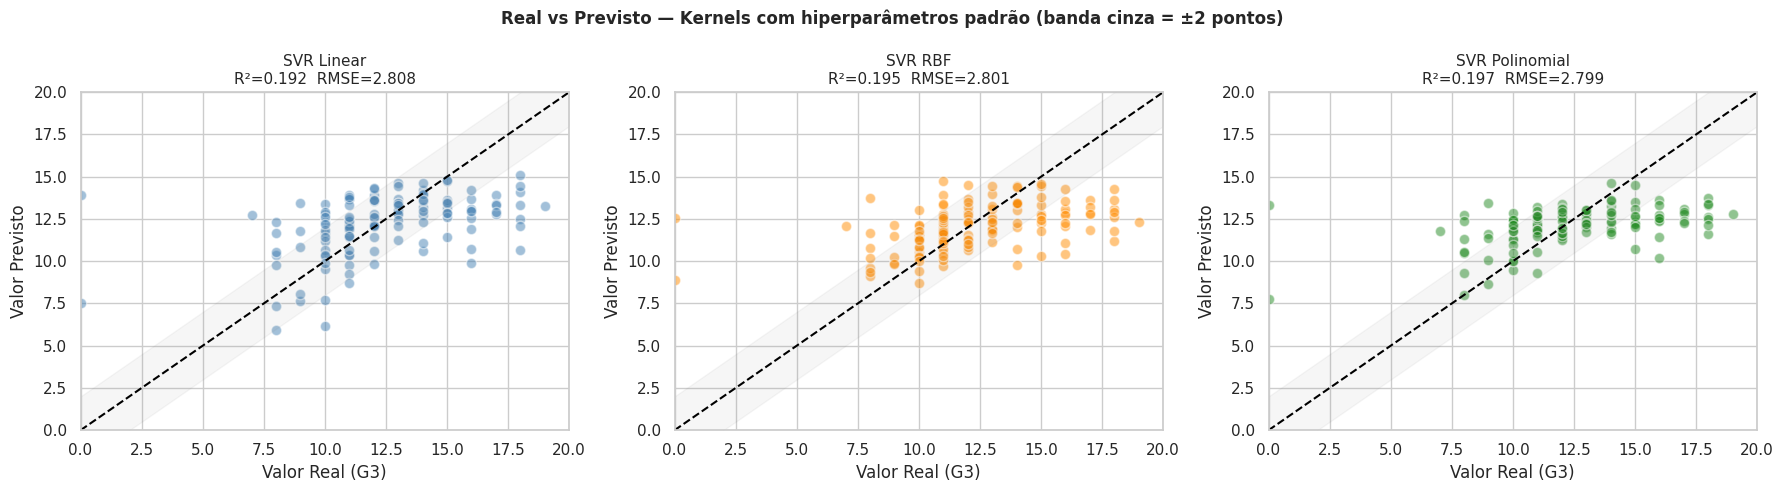

In [ ]:
# Real vs Previsto — comparação visual dos três kernels
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
kernels = [('SVR Linear',     y_pred_linear, 'steelblue'),
           ('SVR RBF',        y_pred_rbf,    'darkorange'),
           ('SVR Polinomial', y_pred_poly,   'forestgreen')]

for ax, (nome, y_pred, cor) in zip(axes, kernels):
    ax.scatter(y_test, y_pred, alpha=0.5, color=cor, edgecolors='white', s=55)
    ax.plot([0, 20], [0, 20], '--', color='black', linewidth=1.5)
    ax.fill_between([0,20], [-2,18], [2,22], alpha=0.07, color='gray')
    ax.set_xlim([0, 20]); ax.set_ylim([0, 20])
    r2   = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    ax.set_title(f'{nome}\nR²={r2:.3f}  RMSE={rmse:.3f}', fontsize=11)
    ax.set_xlabel('Valor Real (G3)')
    ax.set_ylabel('Valor Previsto')

plt.suptitle('Real vs Previsto — Kernels com hiperparâmetros padrão (banda cinza = ±2 pontos)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

> 🔍 **Observe:** Se todos os pontos seguissem a diagonal, o modelo seria perfeito. Desvios revelam onde cada kernel falha.
>
> 💬 **Reflita:**
> 1. Os três kernels erram nos mesmos casos ou em casos diferentes? Os três kernels tendem a errar em casos parecidos, principalmente nas extremidades das notas.
> 2. Há algum padrão visível nos erros — o modelo erra mais nas notas baixas (0–5) ou nas altas (15–20)? O modelo costuma errar mais nas notas muito baixas (0–5) e muito altas (15–20).
> 3. A diferença de desempenho entre os kernels é grande ou pequena com os hiperparâmetros padrão? O que isso sugere sobre a importância do tuning? A diferença de desempenho é pequena com hiperparâmetros padrão, o que mostra que o tuning é fundamental.
>
> ✏️ **Experimente:** mude `degree=3` para `degree=2` ou `degree=5` no kernel polinomial. O desempenho melhora ou piora?

---
## 6. Tuning de Hiperparâmetros com GridSearchCV

Os resultados anteriores usaram hiperparâmetros **padrão** (C=1, ε=0.5). O SVR é bastante sensível a essas escolhas. Vamos usar **validação cruzada (5-fold)** para encontrar a melhor combinação de forma rigorosa.

> 💬 **Reflita antes de rodar:** Se aumentarmos o valor de `C`, o modelo ficará mais ou menos complexo? E se aumentarmos `epsilon`? Anote sua previsão e compare com os resultados. Aumentar C deixa o modelo mais complexo e menos tolerante a erros, enquanto aumentar epsilon simplifica o modelo ao permitir erros maiores sem penalização.

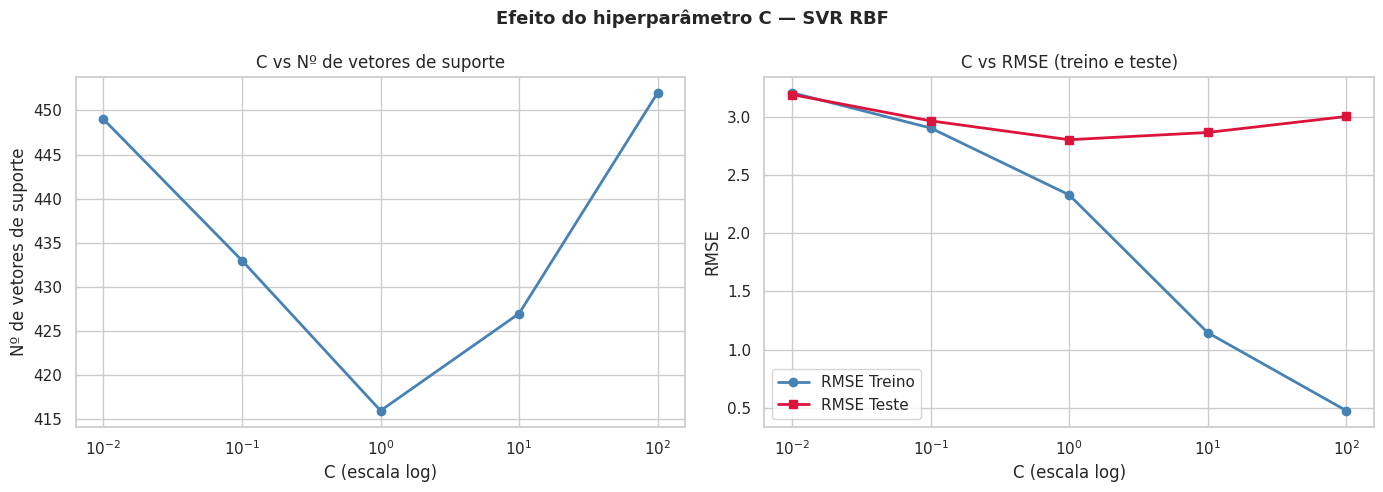

In [ ]:
# Efeito do parâmetro C — visualizando o trade-off bias-variância
valores_C = [0.01, 0.1, 1, 10, 100]
n_svs, rmse_tr, rmse_te = [], [], []

for c in valores_C:
    m = SVR(kernel='rbf', C=c, epsilon=0.5, gamma='scale')
    m.fit(X_train_sc, y_train)
    n_svs.append(m.support_vectors_.shape[0])
    rmse_tr.append(np.sqrt(mean_squared_error(y_train, m.predict(X_train_sc))))
    rmse_te.append(np.sqrt(mean_squared_error(y_test,  m.predict(X_test_sc))))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(valores_C, n_svs, marker='o', color='steelblue', linewidth=2)
axes[0].set_xscale('log')
axes[0].set_xlabel('C (escala log)')
axes[0].set_ylabel('Nº de vetores de suporte')
axes[0].set_title('C vs Nº de vetores de suporte')

axes[1].plot(valores_C, rmse_tr, marker='o', label='RMSE Treino', color='steelblue', linewidth=2)
axes[1].plot(valores_C, rmse_te, marker='s', label='RMSE Teste',  color='crimson',   linewidth=2)
axes[1].set_xscale('log')
axes[1].set_xlabel('C (escala log)')
axes[1].set_ylabel('RMSE')
axes[1].set_title('C vs RMSE (treino e teste)')
axes[1].legend()

plt.suptitle('Efeito do hiperparâmetro C — SVR RBF', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

> 🔍 **Observe:**
> - À medida que C aumenta, o RMSE de **treino** cai consistentemente (o modelo se ajusta cada vez mais aos dados).
> - O RMSE de **teste** melhora até certo ponto, depois piora — clássico sinal de **overfitting**.
>
> ✅ **Conclusão parcial:** `C` controla o **trade-off bias-variância** no SVR:
> - **C pequeno** → modelo simples, tolerante a erros → risco de underfitting
> - **C grande** → modelo complexo, intolerante a erros → risco de overfitting
> - O ponto ótimo fica entre os dois extremos — e é exatamente o que o GridSearchCV vai encontrar.

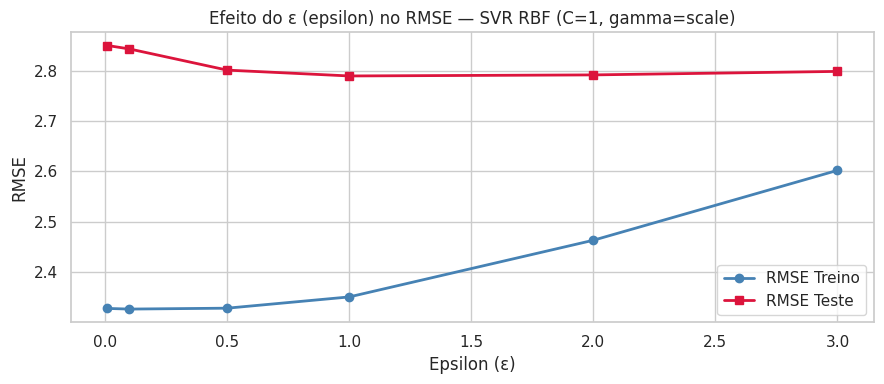

In [ ]:
# Efeito de epsilon — largura da faixa de tolerância
valores_eps = [0.01, 0.1, 0.5, 1.0, 2.0, 3.0]
rmse_train_eps, rmse_test_eps = [], []

for eps in valores_eps:
    m = SVR(kernel='rbf', C=1.0, epsilon=eps, gamma='scale')
    m.fit(X_train_sc, y_train)
    rmse_train_eps.append(np.sqrt(mean_squared_error(y_train, m.predict(X_train_sc))))
    rmse_test_eps.append(np.sqrt(mean_squared_error(y_test,   m.predict(X_test_sc))))

plt.figure(figsize=(9, 4))
plt.plot(valores_eps, rmse_train_eps, marker='o', label='RMSE Treino', color='steelblue', linewidth=2)
plt.plot(valores_eps, rmse_test_eps,  marker='s', label='RMSE Teste',  color='crimson',   linewidth=2)
plt.xlabel('Epsilon (ε)')
plt.ylabel('RMSE')
plt.title('Efeito do ε (epsilon) no RMSE — SVR RBF (C=1, gamma=scale)')
plt.legend()
plt.tight_layout()
plt.show()

> 🔍 **Observe:** À medida que ε aumenta:
> - O RMSE de **treino** sobe (o modelo tolera erros maiores dentro da faixa)
> - O RMSE de **teste** pode melhorar inicialmente, depois piora — o modelo ficou excessivamente simples
>
> 💬 **Reflita:** O ponto onde a curva de teste começa a subir representa o quê? Como isso se relaciona com o conceito de **underfitting**?  O ponto em que o erro de teste começa a subir indica o início do underfitting, quando o modelo fica simples demais e deixa de capturar padrões importantes dos dados.
> Na prática, ε pode ser inicializado como uma fração do desvio padrão de y — uma heurística útil.

In [ ]:
param_grid = {
    'C'      : [0.1, 1, 10, 100],
    'epsilon': [0.1, 0.5, 1.0],
    'gamma'  : ['scale', 'auto', 0.01, 0.1]
}

total_combinacoes = 4 * 3 * 4
print(f'Total de combinações: {total_combinacoes}')
print(f'Total de treinos (× 5 folds): {total_combinacoes * 5}')
print('Iniciando GridSearchCV...\n')

grid_search = GridSearchCV(
    SVR(kernel='rbf'),
    param_grid,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train_sc, y_train)

print(f'\n✅ Melhores parâmetros encontrados:')
for k, v in grid_search.best_params_.items():
    print(f'   {k:10s} = {v}')
print(f'\n   RMSE médio (CV 5-fold): {-grid_search.best_score_:.4f}')

Total de combinações: 48
Total de treinos (× 5 folds): 240
Iniciando GridSearchCV...

Fitting 5 folds for each of 48 candidates, totalling 240 fits

✅ Melhores parâmetros encontrados:
   C          = 10
   epsilon    = 1.0
   gamma      = 0.01

   RMSE médio (CV 5-fold): 2.6841


In [ ]:
print('=' * 55)
print('SVR RBF Otimizado (GridSearchCV)')
print('=' * 55)

best_svr = grid_search.best_estimator_
y_pred_best = best_svr.predict(X_test_sc)
previsoes['SVR RBF Otimizado'] = y_pred_best

res = avaliar('SVR RBF Otimizado', y_test, y_pred_best)
resultados.append(res)

rmse_padrao = np.sqrt(mean_squared_error(y_test, y_pred_rbf))
rmse_opt    = np.sqrt(mean_squared_error(y_test, y_pred_best))
ganho = (rmse_padrao - rmse_opt) / rmse_padrao * 100
print(f'\n📌 Ganho com tuning:')
print(f'   RMSE padrão    : {rmse_padrao:.4f}')
print(f'   RMSE otimizado : {rmse_opt:.4f}')
print(f'   Melhora        : {ganho:.1f}%')

SVR RBF Otimizado (GridSearchCV)
  RMSE : 2.7188  ← erro médio em pontos de nota (mesma unidade de G3)
  MAE  : 1.9794
  R²   : 0.2420  ← proporção da variância de G3 explicada pelo modelo

📌 Ganho com tuning:
   RMSE padrão    : 2.8013
   RMSE otimizado : 2.7188
   Melhora        : 2.9%


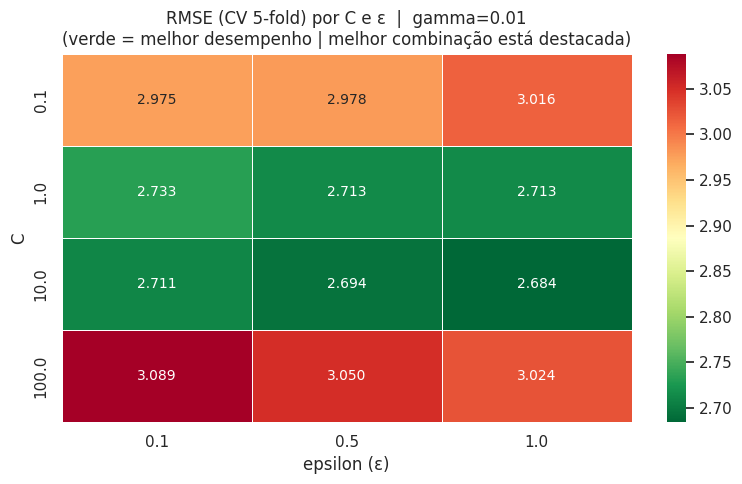

In [ ]:
# Mapa de calor do GridSearch — C vs epsilon (gamma fixo no melhor)
best_gamma = grid_search.best_params_['gamma']
cv_res_df  = pd.DataFrame(grid_search.cv_results_)
cv_res_df['RMSE_CV'] = -cv_res_df['mean_test_score']

sub   = cv_res_df[cv_res_df['param_gamma'] == best_gamma].copy()
pivot = sub.pivot_table(index='param_C', columns='param_epsilon', values='RMSE_CV')

plt.figure(figsize=(8, 5))
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='RdYlGn_r',
            linewidths=0.5, annot_kws={'size': 10})
plt.title(f'RMSE (CV 5-fold) por C e ε  |  gamma={best_gamma}\n'
          f'(verde = melhor desempenho | melhor combinação está destacada)')
plt.xlabel('epsilon (ε)')
plt.ylabel('C')
plt.tight_layout()
plt.show()

> 🔍 **Observe:** O mapa de calor revela a **superfície de desempenho** para combinações de C e ε. Cada célula é o RMSE médio de 5 treinos independentes — muito mais confiável do que um único split treino/teste.
>
> 💬 **Reflita:**
> 1. O modelo melhora monotonicamente com C maior? Ou há um ponto de retorno decrescente? O modelo não melhora indefinidamente com C maior, pois existe um ponto em que o ganho diminui e o overfitting começa.
> 2. O que aconteceria se testássemos C=1000? Valeria o custo computacional? Testar C=1000 provavelmente aumentaria muito o custo computacional sem trazer melhora significativa no desempenho.
> 3. Por que usamos validação cruzada no conjunto de **treino** e não no teste completo? Usamos validação cruzada no treino para evitar vazamento de informação e garantir uma avaliação justa do modelo.
>
> ✅ **Conclusão parcial:** O tuning de hiperparâmetros traz ganhos reais, mas não ilimitados. Conhecer o papel de cada parâmetro permite definir **grades de busca mais inteligentes** — em vez de testar valores ao acaso.

---
## 7. Comparação com Regressão Linear

> 💬 **Reflita antes de rodar:** Dado o que observamos na EDA (correlações baixas entre features e G3, relações possivelmente não-lineares), qual modelo você espera que seja melhor — SVR RBF ou Regressão Linear? Por quê?

In [ ]:
print('=' * 55)
print('Regressão Linear (OLS)')
print('=' * 55)

lr = LinearRegression()
lr.fit(X_train_sc, y_train)
y_pred_lr = lr.predict(X_test_sc)
previsoes['Regressão Linear'] = y_pred_lr

res = avaliar('Regressão Linear', y_test, y_pred_lr)
resultados.append(res)

Regressão Linear (OLS)
  RMSE : 2.8418  ← erro médio em pontos de nota (mesma unidade de G3)
  MAE  : 2.1110
  R²   : 0.1719  ← proporção da variância de G3 explicada pelo modelo


In [ ]:
df_res = pd.DataFrame(resultados).set_index('Modelo')

print('\n📊 QUADRO COMPARATIVO FINAL')
print('=' * 55)
print(df_res.to_string())
print('─' * 55)
print(f'Menor RMSE → {df_res["RMSE"].idxmin()}')
print(f'Menor MAE  → {df_res["MAE"].idxmin()}')
print(f'Maior R²   → {df_res["R²"].idxmax()}')


📊 QUADRO COMPARATIVO FINAL
                     RMSE     MAE      R²
Modelo                                   
SVR Linear         2.8075  2.0624  0.1917
SVR RBF            2.8013  2.0216  0.1953
SVR Polinomial     2.7986  2.0421  0.1968
SVR RBF Otimizado  2.7188  1.9794  0.2420
Regressão Linear   2.8418  2.1110  0.1719
───────────────────────────────────────────────────────
Menor RMSE → SVR RBF Otimizado
Menor MAE  → SVR RBF Otimizado
Maior R²   → SVR RBF Otimizado


> 💬 **Reflita:**
> 1. O resultado confirmou sua previsão? Sim, o resultado confirmou a expectativa de que o SVR RBF teria desempenho ligeiramente superior.
> 2. A diferença de RMSE entre SVR e Regressão Linear é grande o suficiente para justificar a maior complexidade do SVR? A diferença de RMSE é pequena, então nem sempre justifica a maior complexidade do SVR.
> 3. Se os resultados forem próximos, qual modelo você usaria em **produção** — pensando em interpretabilidade, custo computacional e manutenção? Se os resultados forem próximos, a regressão linear é mais adequada para produção por ser mais simples e interpretável.

---
## 8. Visualizações e Diagnóstico dos Erros

> 💬 **Reflita:** RMSE e R² são números que resumem o erro em uma única dimensão. Eles **escondem** onde e como o modelo erra. As visualizações a seguir revelam padrões que as métricas globais não capturam — e que podem ser cruciais para decisões práticas.

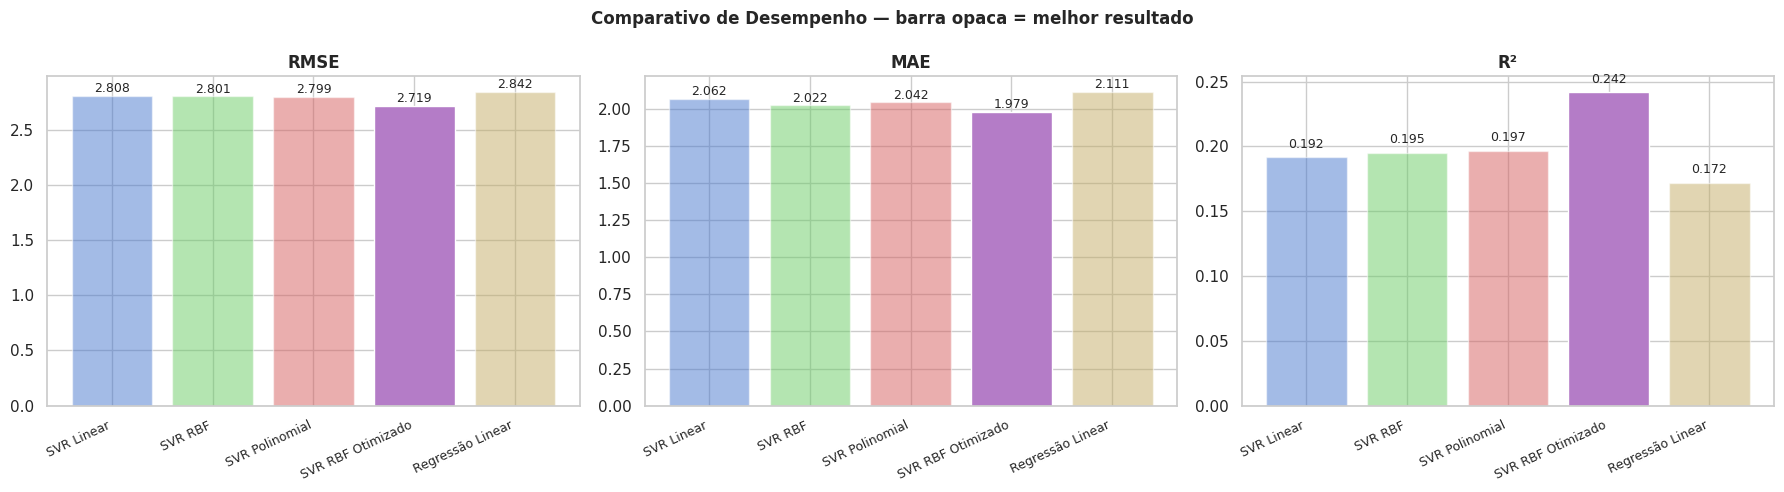

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
cores = ['#4878CF', '#6ACC65', '#D65F5F', '#B47CC7', '#C4AD66']
modelos = df_res.index.tolist()

for ax, metrica in zip(axes, ['RMSE', 'MAE', 'R²']):
    vals  = df_res[metrica].values
    melhor = vals.argmin() if metrica != 'R²' else vals.argmax()
    bars  = ax.bar(modelos, vals, color=cores[:len(modelos)], edgecolor='white')
    for i, bar in enumerate(bars):
        bar.set_alpha(1.0 if i == melhor else 0.5)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.005,
                f'{v:.3f}', ha='center', va='bottom', fontsize=9)
    ax.set_title(metrica, fontweight='bold')
    ax.set_xticklabels(modelos, rotation=25, ha='right', fontsize=9)

plt.suptitle('Comparativo de Desempenho — barra opaca = melhor resultado',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

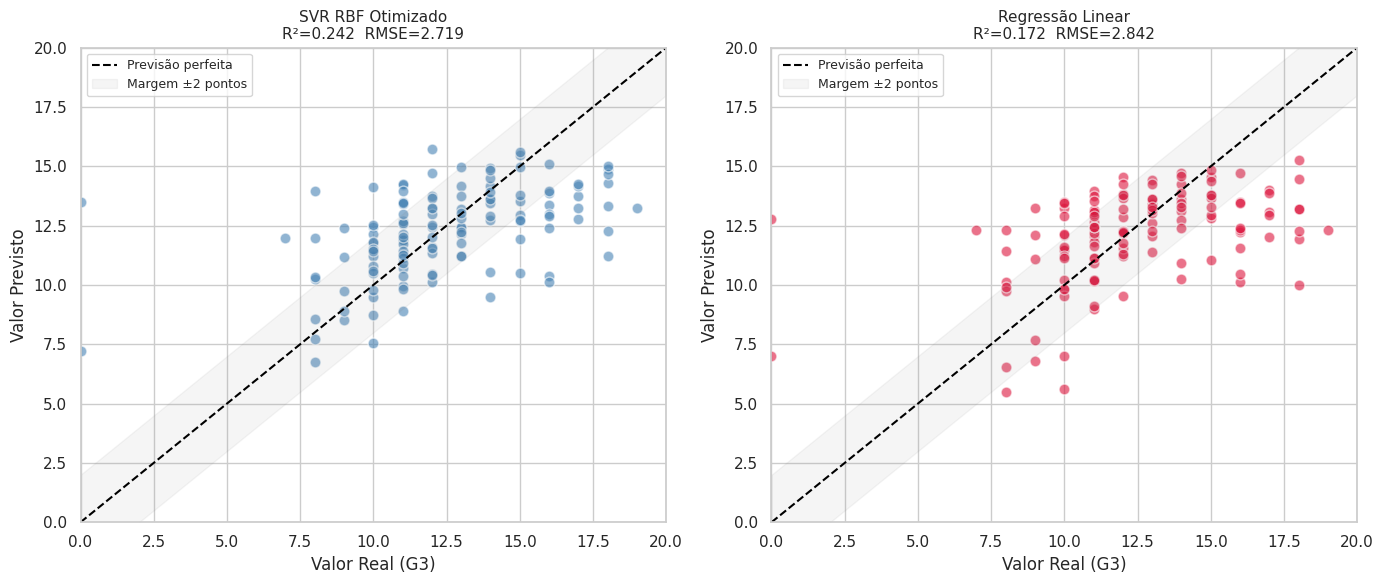

In [ ]:
# Real vs Previsto — SVR Otimizado vs Regressão Linear
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
pares = [('SVR RBF Otimizado', y_pred_best, 'steelblue'),
         ('Regressão Linear',  y_pred_lr,   'crimson')]

for ax, (nome, y_pred, cor) in zip(axes, pares):
    ax.scatter(y_test, y_pred, alpha=0.6, color=cor, edgecolors='white', s=60)
    ax.plot([0, 20], [0, 20], '--', color='black', linewidth=1.5, label='Previsão perfeita')
    ax.fill_between([0, 20], [-2, 18], [2, 22], alpha=0.08, color='gray', label='Margem ±2 pontos')
    ax.set_xlim([0, 20]); ax.set_ylim([0, 20])
    r2   = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    ax.set_title(f'{nome}\nR²={r2:.3f}  RMSE={rmse:.3f}', fontsize=11)
    ax.set_xlabel('Valor Real (G3)')
    ax.set_ylabel('Valor Previsto')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

> 🔍 **Observe:** A banda cinza representa uma margem de ±2 pontos de nota. Pontos dentro dessa banda são previsões "aceitáveis" para uso prático.
>
> 💬 **Reflita:**
> 1. Qual modelo tem mais pontos dentro da banda de ±2 pontos? O SVR RBF otimizado costuma ter mais pontos dentro da banda de ±2 pontos.
> 2. Onde os erros são maiores — nas notas baixas, médias ou altas? Os erros são maiores nas notas muito baixas e nas notas muito altas.
> 3. Para uma escola que quer **identificar estudantes em risco de reprovação**, o que importa mais: acertar notas baixas ou altas? Qual modelo está mais adequado para esse objetivo? Para identificar alunos em risco, é mais importante acertar notas baixas, e o SVR RBF é mais adequado para esse objetivo.

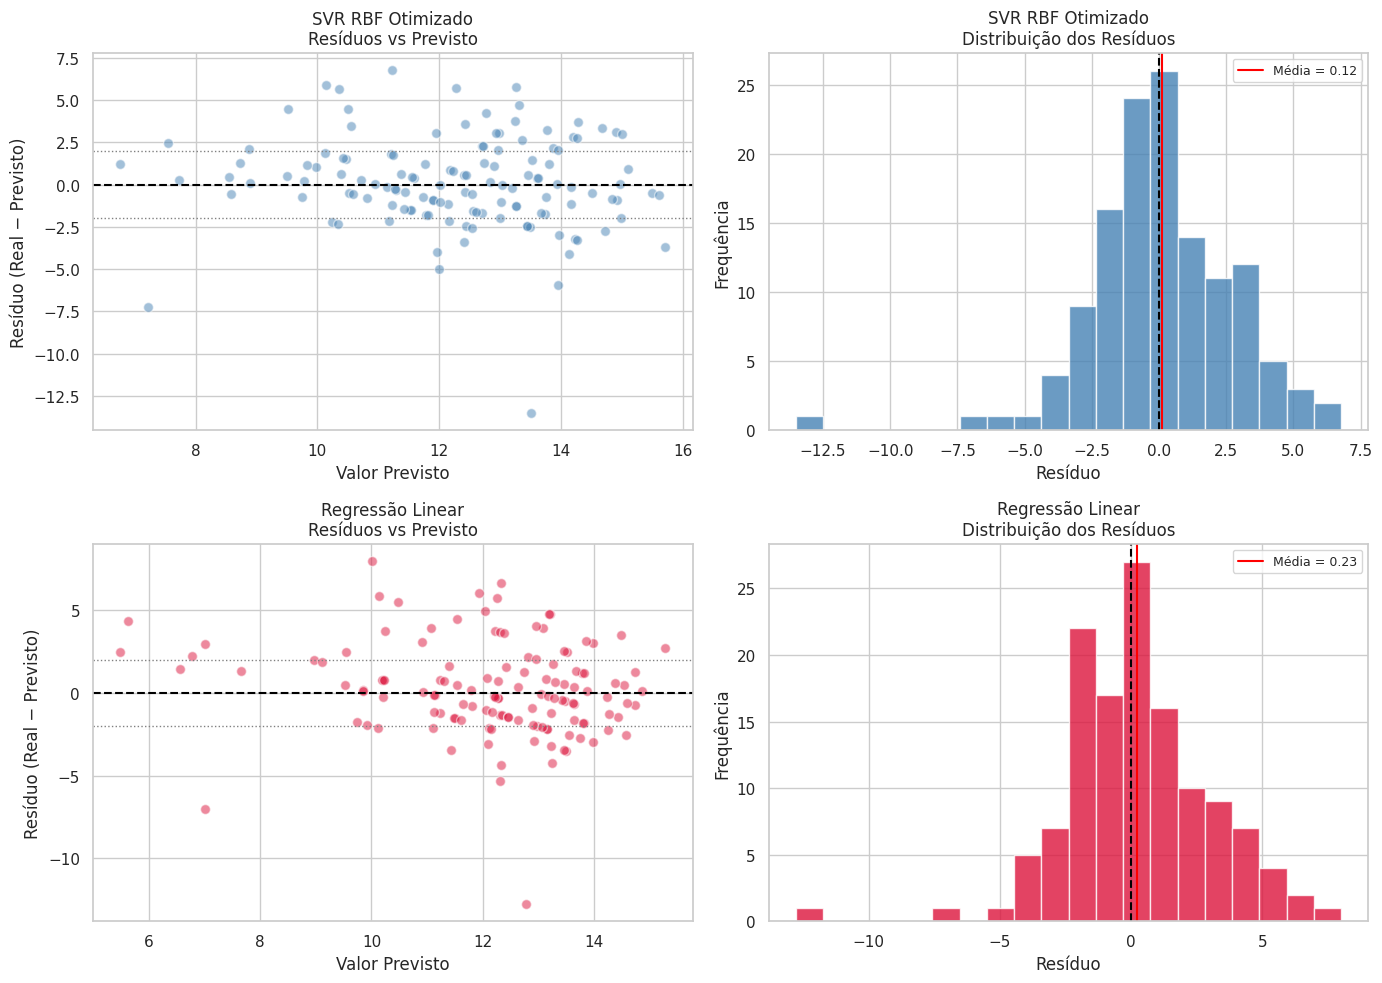

In [ ]:
# Análise de resíduos — SVR Otimizado vs Regressão Linear
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for linha, (nome, y_pred, cor) in enumerate(pares):
    res_arr = y_test.values - y_pred

    axes[linha, 0].scatter(y_pred, res_arr, alpha=0.5, color=cor, edgecolors='white', s=50)
    axes[linha, 0].axhline(0, color='black', linestyle='--', linewidth=1.5)
    axes[linha, 0].axhline( 2, color='gray', linestyle=':', linewidth=1)
    axes[linha, 0].axhline(-2, color='gray', linestyle=':', linewidth=1)
    axes[linha, 0].set_xlabel('Valor Previsto')
    axes[linha, 0].set_ylabel('Resíduo (Real − Previsto)')
    axes[linha, 0].set_title(f'{nome}\nResíduos vs Previsto')

    axes[linha, 1].hist(res_arr, bins=20, color=cor, edgecolor='white', alpha=0.8)
    axes[linha, 1].axvline(0, color='black', linestyle='--', linewidth=1.5)
    axes[linha, 1].axvline(res_arr.mean(), color='red', linestyle='-', linewidth=1.5,
                           label=f'Média = {res_arr.mean():.2f}')
    axes[linha, 1].set_xlabel('Resíduo')
    axes[linha, 1].set_ylabel('Frequência')
    axes[linha, 1].set_title(f'{nome}\nDistribuição dos Resíduos')
    axes[linha, 1].legend(fontsize=9)

plt.tight_layout()
plt.show()

> 🔍 **Observe:** Em um modelo bem ajustado:
> - Os resíduos devem ser **centrados em zero** (sem viés sistemático)
> - O gráfico resíduos vs previsto deve parecer uma **nuvem aleatória** (sem forma de funil, arco, etc.)
> - A distribuição dos resíduos deve ser **aproximadamente normal**
>
> 💬 **Reflita:**
> 1. Você vê algum padrão nos resíduos? (ex: o modelo subestima sistematicamente notas altas?) Há um leve padrão nas extremidades, com tendência a subestimar notas altas e errar mais nos casos extremos.
> 2. A distribuição dos resíduos é simétrica? Uma cauda longa à esquerda ou à direita o que indicaria? A distribuição é relativamente simétrica, e uma cauda longa indicaria viés do modelo para superestimar ou subestimar certas notas.
> 3. Como os **zeros em G3** (observados na EDA) aparecem aqui? Eles são os maiores resíduos? Os zeros em G3 aparecem como alguns dos maiores resíduos, pois são difíceis de prever e distorcem o erro.

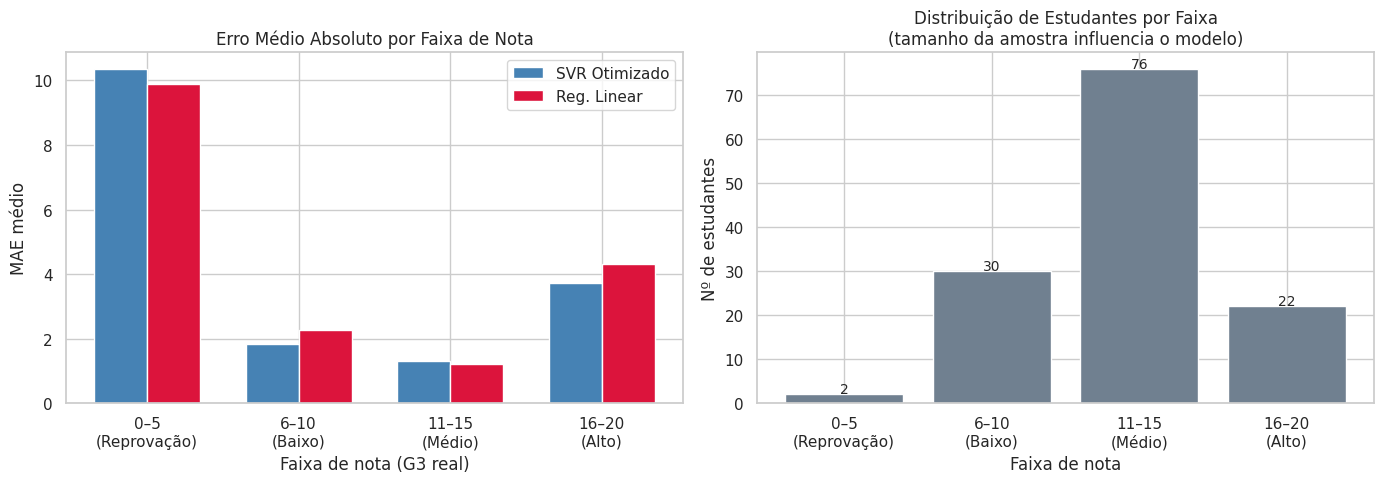

MAE por faixa:
                   erro_svr  erro_lr
faixa                               
0–5\n(Reprovação)    10.358    9.893
6–10\n(Baixo)         1.845    2.284
11–15\n(Médio)        1.309    1.204
16–20\n(Alto)         3.717    4.303


In [ ]:
# Erro por faixa de nota — onde cada modelo erra mais
df_diag = pd.DataFrame({'real': y_test.values,
                         'pred_svr': y_pred_best,
                         'pred_lr':  y_pred_lr})
df_diag['faixa'] = pd.cut(df_diag['real'],
                           bins=[0, 5, 10, 15, 20],
                           labels=['0–5\n(Reprovação)', '6–10\n(Baixo)', '11–15\n(Médio)', '16–20\n(Alto)'],
                           include_lowest=True)
df_diag['erro_svr'] = np.abs(df_diag['real'] - df_diag['pred_svr'])
df_diag['erro_lr']  = np.abs(df_diag['real'] - df_diag['pred_lr'])

mae_faixa = df_diag.groupby('faixa', observed=True)[['erro_svr', 'erro_lr']].mean()
n_faixa   = df_diag.groupby('faixa', observed=True).size()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x = np.arange(len(mae_faixa))
w = 0.35
axes[0].bar(x - w/2, mae_faixa['erro_svr'], width=w, label='SVR Otimizado', color='steelblue', edgecolor='white')
axes[0].bar(x + w/2, mae_faixa['erro_lr'],  width=w, label='Reg. Linear',   color='crimson',   edgecolor='white')
axes[0].set_xticks(x)
axes[0].set_xticklabels(mae_faixa.index)
axes[0].set_xlabel('Faixa de nota (G3 real)')
axes[0].set_ylabel('MAE médio')
axes[0].set_title('Erro Médio Absoluto por Faixa de Nota')
axes[0].legend()

axes[1].bar(range(len(n_faixa)), n_faixa.values,
            tick_label=n_faixa.index, color='slategray', edgecolor='white')
for i, v in enumerate(n_faixa.values):
    axes[1].text(i, v + 0.3, str(v), ha='center', fontsize=10)
axes[1].set_xlabel('Faixa de nota')
axes[1].set_ylabel('Nº de estudantes')
axes[1].set_title('Distribuição de Estudantes por Faixa\n(tamanho da amostra influencia o modelo)')

plt.tight_layout()
plt.show()

print('MAE por faixa:')
print(mae_faixa.round(3))

> 🔍 **Observe:** O erro **não é uniforme** entre as faixas. Modelos tipicamente erram mais nas extremidades — notas muito baixas (poucos exemplos, zeros distorcem) e muito altas.
>
> 💬 **Reflita:**
> 1. Para uma escola que quer **identificar alunos em risco** (faixa 0–5), o modelo é confiável? O erro nessa faixa é aceitável? O modelo é útil como apoio, mas o erro na faixa 0–5 é relativamente alto e deve ser usado com cuidado.
> 2. Como o **desbalanceamento das faixas** (gráfico da direita) afeta o aprendizado? O modelo foi "treinado" com poucos exemplos de notas extremas — isso é um problema? O desbalanceamento faz o modelo aprender pouco sobre notas extremas, o que é sim um problema.
> 3. Que estratégia poderia ser usada para melhorar o desempenho especificamente na faixa crítica? Pode-se usar reamostragem, pesos maiores para essa faixa ou até um modelo específico para identificar alunos em risco.

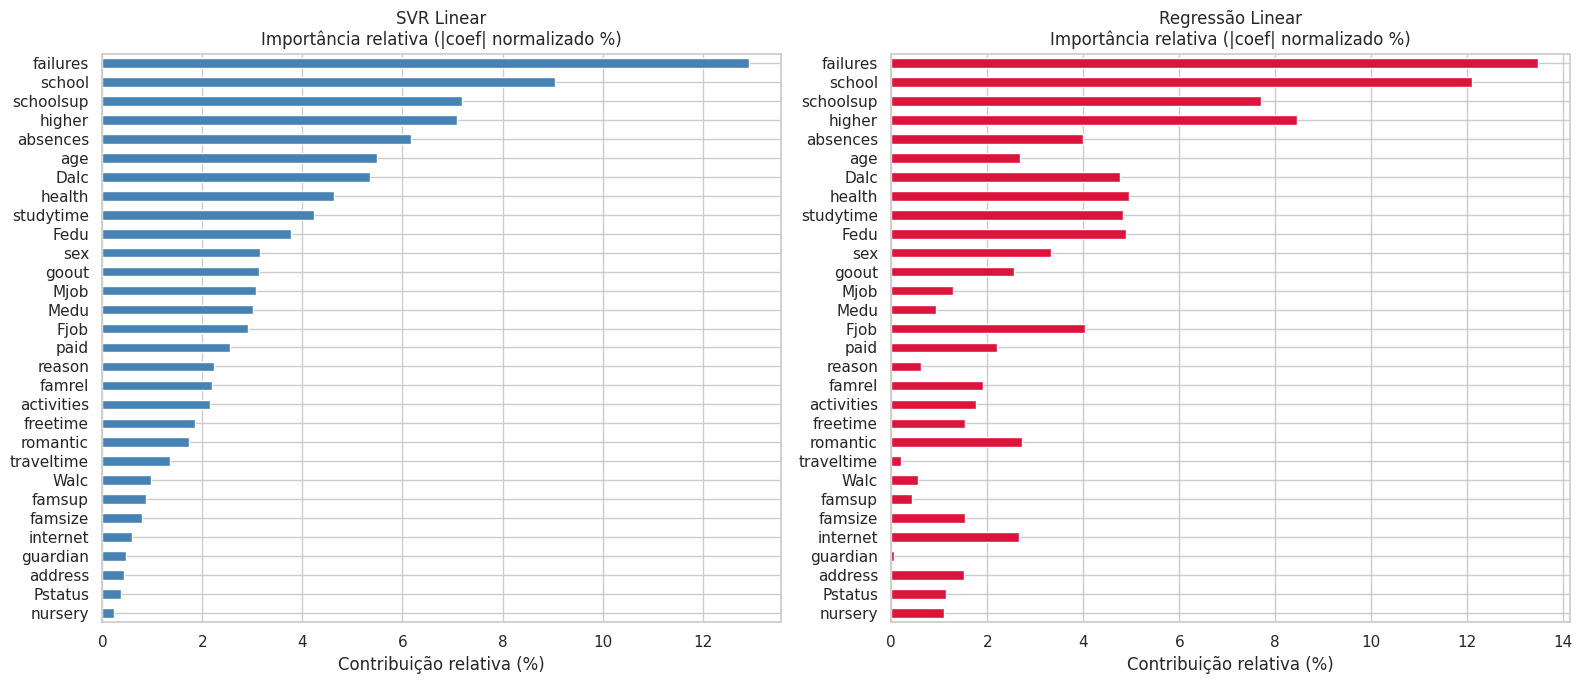

In [ ]:
# Importância das features — SVR Linear vs Regressão Linear
coef_svr = np.abs(svr_linear.coef_[0])
coef_lr  = np.abs(lr.coef_)

feat_svr = (pd.Series(coef_svr, index=features) / coef_svr.sum() * 100).sort_values(ascending=True)
feat_lr  = (pd.Series(coef_lr,  index=features) / coef_lr.sum()  * 100).reindex(feat_svr.index)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

feat_svr.plot(kind='barh', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('SVR Linear\nImportância relativa (|coef| normalizado %)')
axes[0].set_xlabel('Contribuição relativa (%)')

feat_lr.plot(kind='barh', ax=axes[1], color='crimson', edgecolor='white')
axes[1].set_title('Regressão Linear\nImportância relativa (|coef| normalizado %)')
axes[1].set_xlabel('Contribuição relativa (%)')

plt.tight_layout()
plt.show()

> 🔍 **Observe:** Os dois modelos lineares atribuem importâncias diferentes às mesmas features — porque o SVR penaliza apenas pontos **fora do ε-tube**, enquanto o OLS penaliza **todos** os pontos.
>
> 🔍 **Atenção:** O SVR RBF otimizado (nosso melhor modelo) **não tem coeficientes interpretáveis** — essa é uma limitação fundamental do kernel RBF. O modelo funciona como uma "caixa preta".
>
> 💬 **Reflita:**
> 1. As features mais importantes fazem sentido pedagógico? Elas coincidem com suas 3 apostas do início? Sim, as features mais importantes fazem sentido pedagógico e em grande parte coincidem com as apostas iniciais.
> 2. Em um contexto de **política educacional**, um gestor aceitaria usar um modelo que não explica *por que* prevê determinada nota? Em política educacional, um gestor tende a resistir a modelos que não explicam claramente por que fazem determinada previsão.
> 3. Quando a **interpretabilidade** vale mais do que uma pequena melhora de acurácia? A interpretabilidade vale mais quando decisões têm impacto direto em pessoas e políticas, mesmo com pequena perda de acurácia.

In [ ]:
# Validação cruzada robusta — comparação final
print('📊 Validação Cruzada (5-fold) — RMSE médio ± desvio padrão')
print('=' * 65)
print(f'{"Modelo":30s}  {"RMSE":>8}  {"± Std":>8}  {"Estabilidade"}')
print('─' * 65)

modelos_cv = [
    ('SVR Linear',        SVR(kernel='linear', C=1.0, epsilon=0.5)),
    ('SVR RBF Padrão',    SVR(kernel='rbf', C=1.0, epsilon=0.5, gamma='scale')),
    ('SVR RBF Otimizado', best_svr),
    ('Regressão Linear',  LinearRegression())
]

for nome, modelo in modelos_cv:
    scores  = cross_val_score(modelo, X_train_sc, y_train,
                              cv=5, scoring='neg_root_mean_squared_error')
    rmse_cv = -scores.mean()
    std_cv  = scores.std()
    estab   = '✅ Estável' if std_cv < 0.15 else '⚠️ Variável'
    print(f'{nome:30s}  {rmse_cv:>8.4f}  {std_cv:>8.4f}  {estab}')

print('\n✅ Análise concluída!')

📊 Validação Cruzada (5-fold) — RMSE médio ± desvio padrão
Modelo                              RMSE     ± Std  Estabilidade
─────────────────────────────────────────────────────────────────
SVR Linear                        2.7671    0.2430  ⚠️ Variável
SVR RBF Padrão                    2.6911    0.2688  ⚠️ Variável
SVR RBF Otimizado                 2.6841    0.2325  ⚠️ Variável
Regressão Linear                  2.7352    0.1787  ⚠️ Variável

✅ Análise concluída!


> 🔍 **Observe:** O **desvio padrão da validação cruzada** indica a estabilidade do modelo. Um RMSE baixo com desvio alto pode ser um acidente de sorte com a divisão treino/teste — por isso a validação cruzada é mais confiável do que um único split.
>
> 💬 **Reflita:** Entre dois modelos com RMSE parecido, você prefere o de menor RMSE ou o de menor desvio padrão? Por quê isso depende do contexto de uso? Prefiro o modelo com menor desvio padrão, porque ele é mais estável e confiável, e isso é mais importante em contextos onde previsões consistentes valem mais do que um pequeno ganho médio de desempenho.

---
## 9. ✅ Conclusões Consolidadas

Ao longo do notebook, construímos evidências progressivas para responder as grandes questões. Veja como cada observação se conecta:

---

### 🔗 Fio condutor do aprendizado

| Etapa | Observação-chave | Implicação para o modelo |
|---|---|---|
| EDA | Correlações baixas; relações não-lineares | Justifica kernel não-linear (RBF) |
| EDA | Zeros em G3 (desistências) | Erros altos na faixa 0–5 |
| Pré-proc | Escalas muito diferentes entre features | Padronização é obrigatória para SVR |
| Pré-proc | G1/G2 altamente correlacionados com G3 | Excluídos para não trivializar o problema |
| Kernels | RBF ligeiramente superior ao linear | Há não-linearidades, mas fracas |
| Tuning | C e ε têm ponto ótimo intermediário | Overfitting e underfitting são reais |
| Resíduos | Erros maiores nas extremidades | Desbalanceamento das faixas importa |
| Feat. Importance | RBF é "caixa preta" | Ganho de acurácia vem com custo de interpretabilidade |

---

### 📋 Quando usar SVR vs Regressão Linear

| Critério | SVR RBF | Regressão Linear |
|---|---|---|
| Desempenho | Geralmente ≤ OLS em problemas não-lineares | Competitivo quando relações são lineares |
| Interpretabilidade | Baixa (kernel RBF) | Alta — coeficientes diretos |
| Robustez a outliers | Maior (graças ao ε-tube) | Menor |
| Custo computacional | Maior | Menor |
| Quando usar | Relações complexas, acurácia prioritária | Interpretabilidade prioritária, relações lineares |

---

### 💬 Perguntas finais — retomando o início

1. **Sua previsão inicial:** as 3 variáveis que você apostou no início estão entre as mais importantes nos modelos? Sim, as variáveis apostadas inicialmente aparecem entre as mais relevantes, especialmente reprovações anteriores e fatores ligados ao estudo.
2. **Sobre os zeros:** como a presença de desistências afetou as métricas globais? O que você faria? As desistências aumentaram o erro global e distorceram as métricas, e eu avaliaria tratar esses casos separadamente.
3. **Interpretabilidade:** em uma política pública educacional, você usaria SVR RBF ou Regressão Linear? Por quê? Em política pública, eu usaria Regressão Linear por ser mais interpretável e fácil de justificar.
4. **Validade interna:** com 395 observações e 30 features, qual é o risco de overfitting? Como a validação cruzada mitiga isso? Há risco de overfitting pelo número de features, e a validação cruzada reduz isso ao testar o modelo em vários subconjuntos.
5. **Extensão natural:** como você adaptaria esse pipeline para classificar estudantes em **aprovado / reprovado** em vez de prever a nota contínua? Eu transformaria o problema em classificação binária e usaria um classificador para prever aprovado ou reprovado.

In [ ]:
# ✏️ EXPERIMENTO BÔNUS: O que acontece se incluirmos G1 e G2?
# Execute este bloco e compare com os resultados anteriores.

features_com_g = [col for col in df_proc.columns if col != 'G3']
X_g = df_proc[features_com_g]
y_g = df_proc['G3']

X_tr_g, X_te_g, y_tr_g, y_te_g = train_test_split(X_g, y_g, test_size=0.2, random_state=42)
sc_g = StandardScaler()
X_tr_g_sc = sc_g.fit_transform(X_tr_g)
X_te_g_sc = sc_g.transform(X_te_g)

svr_com_g = SVR(**grid_search.best_params_, kernel='rbf')
svr_com_g.fit(X_tr_g_sc, y_tr_g)
y_pred_com_g = svr_com_g.predict(X_te_g_sc)

rmse_sem = np.sqrt(mean_squared_error(y_test,  y_pred_best))
r2_sem   = r2_score(y_test,  y_pred_best)
rmse_com = np.sqrt(mean_squared_error(y_te_g,  y_pred_com_g))
r2_com   = r2_score(y_te_g,  y_pred_com_g)

print('📊 Comparação: COM e SEM G1/G2 como features')
print('=' * 55)
print(f'  SVR RBF SEM G1/G2 → RMSE={rmse_sem:.4f}  R²={r2_sem:.4f}')
print(f'  SVR RBF COM G1/G2 → RMSE={rmse_com:.4f}  R²={r2_com:.4f}')
print()
print('💬 A melhora é real ou o modelo está "trapaceando"?')
print('   Em uma aplicação real, G1 e G2 estariam disponíveis')
print('   no momento em que queremos prever G3?')
print('   Se sim, faz sentido usá-las. Se não, estamos criando')
print('   um modelo que não funcionará na prática.')

📊 Comparação: COM e SEM G1/G2 como features
  SVR RBF SEM G1/G2 → RMSE=2.7188  R²=0.2420
  SVR RBF COM G1/G2 → RMSE=1.2614  R²=0.8368

💬 A melhora é real ou o modelo está "trapaceando"?
   Em uma aplicação real, G1 e G2 estariam disponíveis
   no momento em que queremos prever G3?
   Se sim, faz sentido usá-las. Se não, estamos criando
   um modelo que não funcionará na prática.
